
# Lab 8: Quantun Computing - Rabi Oscillations



* ## Angélica Vanegas C.C 1000290572

## Exercise 1: $NH_3$ molecule

An example of the quantum oscillations in two-level systems may be rather unexpected; for example, the ammonium molecule

 It has two symmetric states that differ by the inversion of the nitrogen atom relative to the plane of the three hydrogen atoms, which are weakly coupled due to quantum-mechanical tunneling of the nitrogen atom through the plane of the hydrogen atoms. Since for this particular molecule, in the absence of external fields, the level splitting $\Delta E$ corresponds to an experimentally convenient frequency $\Omega/2\pi\approx$ 24.79 GHz.

 1. Supose a detuning frequency $\Omega_R/2$.
 2. Compute the Rabi frequency for NH3 molecule in Hz and do a plot of the Rabi oscillation. Supose that the initial state is ∣2⟩.

 [see](https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Essential_Graduate_Physics_-_Quantum_Mechanics_(Likharev)/05%3A_Some_Exactly_Solvable_Problems/5.01%3A_Two-level_Systems)

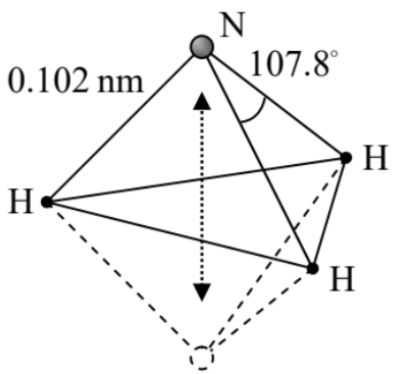

In [21]:
from IPython.display import Image, display
display(Image("NH3.png"))

# Solución

La frecuencia de Rabi general es:

$Ω_{rabi}$ = $\sqrt{Ω_R^2+Ω^2}$ donde:

$Ω$: frecuencia natural del sistema, $Ω_R$ detuning y nos dan:

$\frac{Ω}{2π} = 24.79 GHz$

y la probabilidad de trasicion es:

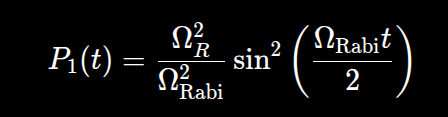


de lo visto en el curso y en mecánica cuántica.

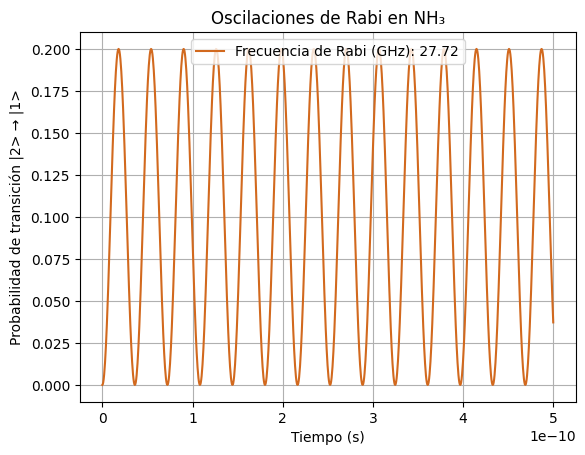

In [2]:
#@title Grafiquita

import numpy as np
import matplotlib.pyplot as plt

# frecuencia natural del NH3
Omega = 2*np.pi*24.79e9  # rad/s

# detuning
Omega_R = Omega / 2

# frecuencia de Rabi
Omega_Rabi = np.sqrt(Omega**2 + Omega_R**2)
f_Rabi_GHz = Omega_Rabi / (2*np.pi*1e9)

t = np.linspace(0, 5e-10, 1000)
P1 = (Omega_R**2 / Omega_Rabi**2) * np.sin(Omega_Rabi*t/2)**2 #probabilidad de transición

plt.plot(t, P1, color = "chocolate", label = f"Frecuencia de Rabi (GHz): {round(f_Rabi_GHz, 2)}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Probabilidad de transición |2> → |1>")
plt.title("Oscilaciones de Rabi en NH₃")
plt.legend(loc="upper center")
plt.grid()
plt.show()


Los resultados muestran que el sistema de dos niveles asociado al NH
3 presenta oscilaciones de Rabi, en las cuales la probabilidad de transición entre los estados ∣2⟩ y ∣1⟩ oscila periódicamente en el tiempo. La frecuencia de estas oscilaciones está dada por la frecuencia de Rabi, que depende tanto de frecuencias natural del sistema como del detuning. Esto confirma el comportamiento esperado de un sistema cuántico de dos niveles sometido a interacción externa.

## Exercise: Bell state

1. Creates a quantum circuit for two qubits, consisting of the quantum gates needed to create a `Bell state`  (two entangled qubits). The quantum circuit then terminates with quantum measurements, extracting one bit from each qubit.

2. Add a third qubit by changing to QuantumCircuit(3), and add a second CX gate with qc.cx(1,2). The measurements should then change to 000 and 111, which means all three of these qubits have been entangled.

3. See your results shift by adding qc.x(1) to the end of the circuit.

# Vamos a seguir el ejemplo visto en clase, para dos qubits

In [3]:
!pip install qiskit

In [4]:
import qiskit
qiskit.__version__

'2.4.1'

In [5]:
!pip install pylatexenc

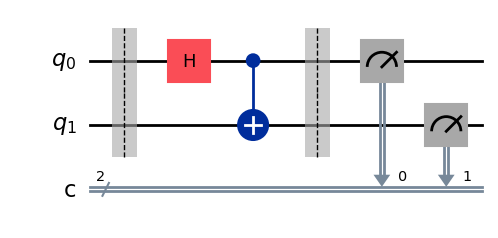

In [6]:
#@title Para dos qubits, visto en clase

from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

q_bell = QuantumCircuit(2,2)

q_bell.barrier()
q_bell.h(0)
q_bell.cx(0,1)
q_bell.barrier()

q_bell.measure([0,1],[0,1])

q_bell.draw(output='mpl', plot_barriers=True)

In [11]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.8 MB/s eta 0:00:00


{'11': 518, '00': 482}


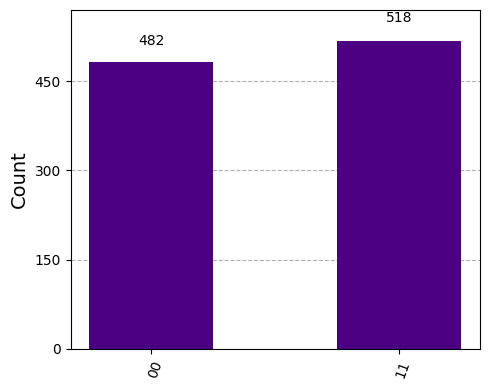

In [15]:
# 1. Update your imports
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer  # Se ha cambiado de qiskit import Aer a qiskit_aer import Aer. IBM corretion
from qiskit.visualization import plot_histogram

# 2. Set up your backend
backend = Aer.get_backend('qasm_simulator') # locally

# 3. Transpile the circuit for your specific backend. transport compilation
compiled_circuit = transpile(q_bell, backend)

# 4. Run the circuit using the backend's run method.
job = backend.run(compiled_circuit, shots=1000) # shots: number of times to run the circuit

result_sim = job.result()

print(result_sim.get_counts(q_bell))
plot_histogram(result_sim.get_counts(q_bell),figsize=(5,4), color = "indigo")

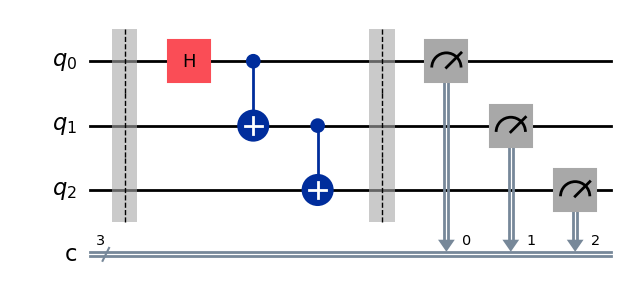

In [13]:
#@title Para 3 qubits, usando de base el código del profe

q_3 = QuantumCircuit(3,3) #con esto agregamos otro qubit al sistema

q_3.barrier()

q_3.h(0)      #entrada hadamard, que es la que realiza esta "superposición" positiva y negativa depende si estamos en ∣0⟩ o ∣1⟩
q_3.cx(0,1)
q_3.cx(1,2)   #agregramos una segunda compuerta CNOT que funciona mandando estas entradas Entrada∣00⟩∣01⟩∣10⟩∣11⟩ a las salidas ∣00⟩∣01⟩∣11⟩∣10⟩, respectivamente

q_3.barrier()
q_3.measure([0,1,2],[0,1,2])

q_3.draw(output='mpl', plot_barriers=True)

{'111': 489, '000': 511}


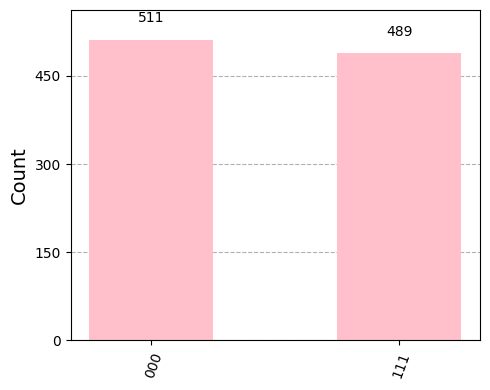

In [16]:
#@title Grafiquita

backend = Aer.get_backend("qasm_simulator")

compiled_circuit = transpile(q_3, backend)

job = backend.run(compiled_circuit, shots=1000)

result_sim = job.result()

counts = result_sim.get_counts(q_3)

print(counts)

plot_histogram(counts, figsize=(5,4), color = "pink")

{'101': 503, '010': 497}


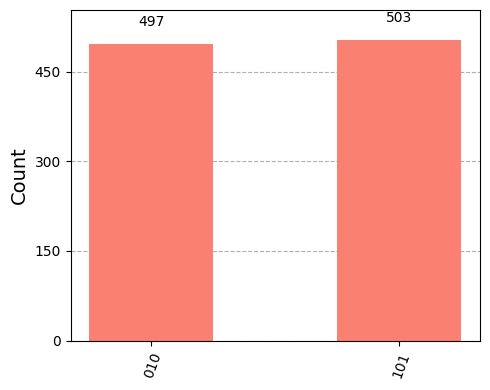

In [20]:
#@title Ahora agregando qc.x(1) con histograma

qc = QuantumCircuit(3,3)

qc.h(0)
qc.cx(0,1)
qc.cx(1,2)

qc.x(1) #agregando, recordemos que esta compuesta agrega un NOT cuántico, X∣0⟩=∣1⟩ y X∣1⟩=∣0⟩

qc.measure([0,1,2],[0,1,2])

backend = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(qc, backend)
job = backend.run(compiled_circuit, shots=1000)

result = job.result()
counts = result.get_counts()

print(counts)
plot_histogram(counts, figsize=(5,4), color = "salmon")

## Los resultados muestran que, antes de aplicar la compuerta X, las mediciones se concentran en los estados 000 y 111, evidenciando el entrelazamiento de los tres qubits.

## Después de aplicar X, las mediciones cambian a 010 y 101, tal como funciona esta compuerta, confirmando que el circuito funciona correctamente y demuestra cómo una operación sobre un solo qubit puede modificar las correlaciones de todo el sistema cuántico.

Nota: 5.0... muy bien por acercarse a estos temas. 